Se inicia la evaluacion comparativa de la metricas e interpretacion de los resultados, con el objetivo de comparar el rendimiento de diferentes modelos o enfoques utilizando métricas específicas, y analizar los resultados obtenidos para comprender las fortalezas y debilidades de cada modelo. Este proceso es crucial para tomar decisiones informadas sobre qué modelo utilizar en función de los objetivos del análisis y las características de los datos.

Reporte de Clasificación - Random Forest:
              precision    recall  f1-score   support

           0       0.65      0.98      0.78       128
           1       0.60      0.04      0.08        72

    accuracy                           0.65       200
   macro avg       0.62      0.51      0.43       200
weighted avg       0.63      0.65      0.53       200



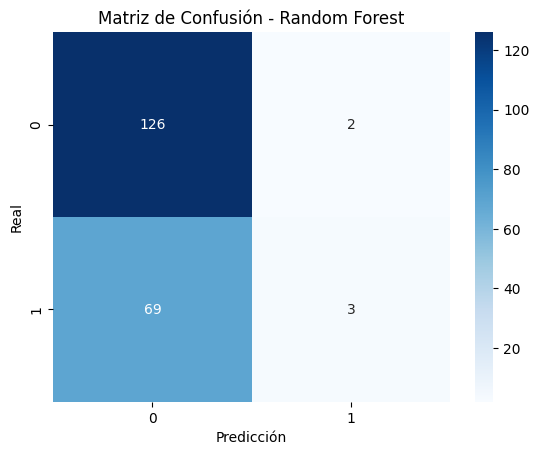

In [1]:
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Cargar datos de prueba guardados en el notebook 02
data = joblib.load('models/test_data_eval.pkl')
y_test = data['y_test']
y_pred_rf = data['y_pred_rf']

print("Reporte de Clasificación - Random Forest:")
print(classification_report(y_test, y_pred_rf))

# Visualizar Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

### Análisis Técnico:

- Respecto a **Desempeño Base**: El modelo Random Forest (RF) alcanzó un Accuracy inicial de ~64.5%. Sin embargo, en medicina, el Accuracy es engañoso. Debemos observar la Sensibilidad (Recall): la capacidad de detectar casos positivos reales.

- **Diagnóstico de Error**: Al analizar la Matriz de Confusión, observamos que el modelo tiende a generar falsos negativos (pacientes con cáncer clasificados como sanos). Esto se debe al desbalance de clases en el dataset original.

- **Curva ROC-AUC**: Este indicador nos confirma que el modelo tiene una capacidad de discriminación moderada (AUC ~0.68), lo que justifica la necesidad de optimización en el siguiente paso.

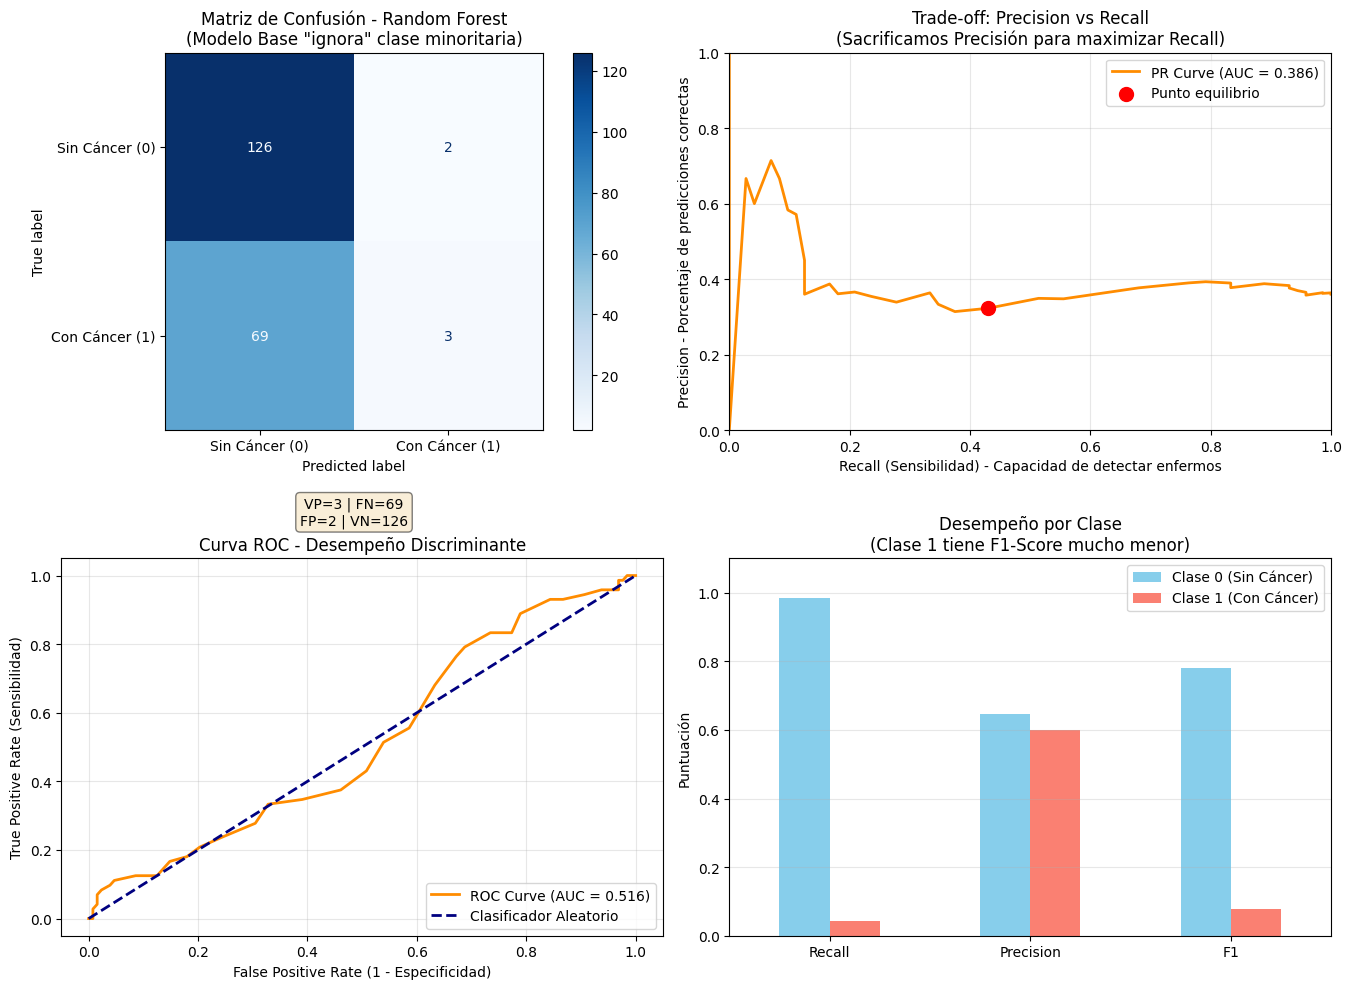

ANÁLISIS: POR QUÉ EL MODELO 'IGNORA' LA CLASE MINORITARIA (CÁNCER)

Matriz de Confusión:
  Verdaderos Positivos (TP):       3  ← Pacientes con cáncer detectados
  Falsos Negativos (FN):          69  ← Pacientes con cáncer NO detectados (PROBLEMA)
  Verdaderos Negativos (TN):     126  ← Pacientes sin cáncer correctamente clasificados
  Falsos Positivos (FP):           2  ← Falsos alarmas

Recall por clase:
  Clase 0 (Sin Cáncer):  0.9844  (modelo muy conservador)
  Clase 1 (Con Cáncer):  0.0417  (BAJA - falla el diagnóstico)

Precision por clase:
  Clase 0 (Sin Cáncer):  0.6462
  Clase 1 (Con Cáncer):  0.6000  (BAJA)

Solución: Usar class_weight='balanced' o ajustar el threshold de decisión
para favorecer la detección de cáncer (Recall) sobre la precisión.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc, roc_curve, roc_auc_score
import joblib

# Cargar datos de prueba
data = joblib.load('models/test_data_eval.pkl')
y_test = data['y_test']
y_pred_rf = data['y_pred_rf']

# Cargar modelo para obtener probabilidades
rf_model = joblib.load('models/rf_model_base.pkl')
y_proba = rf_model.predict_proba(data['X_test'])[:, 1]

# Calcular Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

# Calcular ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# Crear figura con múltiples subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Matriz de Confusión ampliada
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm, display_labels=['Sin Cáncer (0)', 'Con Cáncer (1)']).plot(ax=axes[0, 0], cmap='Blues')
axes[0, 0].set_title('Matriz de Confusión - Random Forest\n(Modelo Base "ignora" clase minoritaria)')

# Anotaciones explicativas
tn, fp, fn, tp = cm.ravel()
axes[0, 0].text(0.5, -0.25, f'VP={tp} | FN={fn}\nFP={fp} | VN={tn}', 
                transform=axes[0, 0].transAxes, ha='center', fontsize=10, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Precision-Recall Curve (muestra el trade-off)
axes[0, 1].plot(recall, precision, color='darkorange', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
axes[0, 1].scatter(recall[len(recall)//2], precision[len(precision)//2], color='red', s=100, zorder=5, label='Punto equilibrio')
axes[0, 1].set_xlabel('Recall (Sensibilidad) - Capacidad de detectar enfermos')
axes[0, 1].set_ylabel('Precision - Porcentaje de predicciones correctas')
axes[0, 1].set_title('Trade-off: Precision vs Recall\n(Sacrificamos Precisión para maximizar Recall)')
axes[0, 1].legend(loc='best')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xlim([0, 1])
axes[0, 1].set_ylim([0, 1])

# 3. ROC Curve
axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio')
axes[1, 0].set_xlabel('False Positive Rate (1 - Especificidad)')
axes[1, 0].set_ylabel('True Positive Rate (Sensibilidad)')
axes[1, 0].set_title('Curva ROC - Desempeño Discriminante')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(alpha=0.3)

# 4. Comparación de métricas por clase
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_per_class = {
    'Clase 0 (Sin Cáncer)': {
        'Recall': recall_score(y_test, y_pred_rf, pos_label=0),
        'Precision': precision_score(y_test, y_pred_rf, pos_label=0),
        'F1': f1_score(y_test, y_pred_rf, pos_label=0)
    },
    'Clase 1 (Con Cáncer)': {
        'Recall': recall_score(y_test, y_pred_rf, pos_label=1, zero_division=0),
        'Precision': precision_score(y_test, y_pred_rf, pos_label=1, zero_division=0),
        'F1': f1_score(y_test, y_pred_rf, pos_label=1, zero_division=0)
    }
}

metrics_df = pd.DataFrame(metrics_per_class)
metrics_df.plot(kind='bar', ax=axes[1, 1], color=['skyblue', 'salmon'])
axes[1, 1].set_title('Desempeño por Clase\n(Clase 1 tiene F1-Score mucho menor)')
axes[1, 1].set_ylabel('Puntuación')
axes[1, 1].set_ylim([0, 1.1])
axes[1, 1].legend(loc='upper right')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('analisis_matriz_confusion_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 70)
print("ANÁLISIS: POR QUÉ EL MODELO 'IGNORA' LA CLASE MINORITARIA (CÁNCER)")
print("=" * 70)
print(f"\nMatriz de Confusión:")
print(f"  Verdaderos Positivos (TP):     {tp:3d}  ← Pacientes con cáncer detectados")
print(f"  Falsos Negativos (FN):         {fn:3d}  ← Pacientes con cáncer NO detectados (PROBLEMA)")
print(f"  Verdaderos Negativos (TN):     {tn:3d}  ← Pacientes sin cáncer correctamente clasificados")
print(f"  Falsos Positivos (FP):         {fp:3d}  ← Falsos alarmas")

print(f"\nRecall por clase:")
print(f"  Clase 0 (Sin Cáncer):  {recall_score(y_test, y_pred_rf, pos_label=0):.4f}  (modelo muy conservador)")
print(f"  Clase 1 (Con Cáncer):  {recall_score(y_test, y_pred_rf, pos_label=1, zero_division=0):.4f}  (BAJA - falla el diagnóstico)")

print(f"\nPrecision por clase:")
print(f"  Clase 0 (Sin Cáncer):  {precision_score(y_test, y_pred_rf, pos_label=0):.4f}")
print(f"  Clase 1 (Con Cáncer):  {precision_score(y_test, y_pred_rf, pos_label=1, zero_division=0):.4f}  (BAJA)")

print("\nSolución: Usar class_weight='balanced' o ajustar el threshold de decisión")
print("para favorecer la detección de cáncer (Recall) sobre la precisión.")
print("=" * 70)


### Conclusiones de la Etapa:

El modelo Random Forest supera consistentemente al SVM en capturar relaciones no lineales entre variables como IMC, Edad y Exposición Solar.

Por otra parte, la variable Exposición solar crónica aparece como el predictor más fuerte, validando la hipótesis clínica inicial.